In [83]:
import torch
import torch.nn as nn
import einops
from torch.nn import functional as F


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

with open('../data/input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print("total examples:", len(text))
print("vocab size:", vocab_size)
print(text[:25])

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

block_size = 8
batch_size = 64
def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(low=0, high=len(data)-block_size, size=(batch_size, ))

    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

Xb, Yb = get_batch('train')
print(Xb[0])
print(Yb[0])

cuda
total examples: 1115394
vocab size: 65
First Citizen:
Before we 
tensor([56, 47, 43, 60, 43,  1, 63, 53], device='cuda:0')
tensor([47, 43, 60, 43,  1, 63, 53, 59], device='cuda:0')


In [5]:
n_embd = 16
head_size = 40
n_layer = 10

In [ ]:
class FFN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4*n_embd),
            nn.ReLU(),
            nn.Linear(4*n_embd, n_embd)
        )
    
    def forward(self, x):
        return x + self.net(x)
    
def ScaledDotProductAttention(q, k, v):
    d_k = q.shape[-1]

    wei = q @ k.transpose(-1, -2) * d_k**(-0.5) 

    tril = torch.tril(torch.ones((k.shape[-2], k.shape[-2]), device=device))
    wei = wei.masked_fill(tril == 0, float('-inf'))
    wei = F.softmax(wei, dim=-1)
    out = wei @ v

    return out
    
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        # self.headtoembd = nn.Linear(head_size, n_embd)
    
    def forward(self, x):
        B, T, C = x.shape

        q = self.query(x) 
        k = self.key(x)   # (B,T,hs)
        v = self.value(x)

        out = ScaledDotProductAttention(q, k ,v)
        # out = self.headtoembd(out)
        return out # do residual at the blocks instead

# Multihead Attention
Following the given formula, $\text{MultiHead}(Q, K, V) = \text{Attention}(QW_{i}^{Q}, KW_{i}^{K}, VW_{i}^{V})$, 
the implementation will be similair to embeddings being squashed before a linear layer. Since we're splitting into multiple 
attention heads and concatonating them, let's use `.einsum()` for simplicity and also save memory by using `.view()`. 


2 implementations:

* Instead of 1 head -> 1 output, we do split the 1 head into smaller head_sizes, calculate, and then recombine. Very simply but ehhh in calculations
* Create a mega matrix of qkv weights, then chunk/split the q, k, v with nh dimension and then calc then `.view()` combine. Lowkey hard to see the shapes but better memory.

In [ ]:
n_heads = 4

assert (head_size % n_heads == 0), "not headsize not divisible by number of heads"
class MultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()  
        self.heads = nn.ModuleList([Head(head_size = (head_size // n_heads)) for _ in range(n_heads)])
        self.proj = nn.Linear(head_size, n_embd)
    
    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        return out

In [89]:
# q, k, v = self.qkv_weights(x).split(head_size, dim=2) # (B, T, headsize)
# # now split once more by adding another dimension

# partition_headsize = head_size // n_heads
# q = q.view(B, T, n_heads, partition_headsize).transpose(1,2) # (B, nh, T, hs')   hs' being hs/n_head
# k = k.view(B, T, n_heads, partition_headsize).transpose(1,2)
# v = v.view(B, T, n_heads, partition_headsize).transpose(1,2)

# simplified using permute and chunk
# qkv = self.qkf_weights(x).permute(0, 2, 1, 3).chunk(3, dim=-1)

torch.Size([1, 6])

In [ ]:
class batchedMultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.qkv_weights = nn.Linear(n_embd, 3 * head_size, bias=False)
        self.proj = nn.Linear(head_size, n_embd)

    def forward(self, x):
        B, T, C = x.shape

        qkv =  self.qkv_weights(x) # B, T, 3 * head_size
        q, k, v = tuple(einops.rearrange(qkv, "b t (k nh hs) -> k b nh t hs", k=3, nh=n_heads)) # tuple to remove the 0th dim

        out = ScaledDotProductAttention(q, k ,v)

        # this thing sucks smh
        # out = out.transpose(1, 2).contiguous().view(B, T, head_size) # i forgot u need to switch nh, T smh smh -> also contigous is needed for .transopse
        out = einops.rearrange(out, 'b nh t hs -> b t (nh hs)')
        out = self.proj(out)

        return out

In [104]:
multi = MultiHeadAttention()
better_multi = batchedMultiHeadAttention()
single = Head(head_size=head_size)

proj = nn.Linear(head_size, n_embd, bias=False)

multi.to(device)
single.to(device)
better_multi.to(device)

proj.to(device)

input = torch.randn((1, 4, n_embd), device=device)

print(multi(input).shape)
x = multi(input)
print(better_multi(input).shape)
y = better_multi(input)



torch.Size([1, 4, 16])
torch.Size([1, 4, 16])


In [105]:
qkv_weights = nn.Linear(n_embd, 3 * head_size, bias=False)

qkv_weights.to(device=device)
input = torch.randn((1, 8, n_embd), device=device)
B, T, C, = input.shape

print(input.shape)
print(qkv_weights(input).shape) # B, T, 120 (3 of total head_size) -> split in the into thirds (dim = 2)
q, k, v = qkv_weights(input).split(head_size, dim=2) # now B, T, 40 checks out

print("q's shape:", q.shape)
q = q.view(B, T, n_heads, head_size // n_heads)
print("q into multiple heads" , q.shape)
q = q.transpose(1, 2)
q.shape





torch.Size([1, 8, 16])
torch.Size([1, 8, 120])
q's shape: torch.Size([1, 8, 40])
q into multiple heads torch.Size([1, 8, 4, 10])


torch.Size([1, 4, 8, 10])

In [106]:
class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(n_embd),
            batchedMultiHeadAttention(),
            nn.LayerNorm(n_embd),
            FFN()
        )
        self.ln1 = nn.LayerNorm(n_embd)
        self.multiattn = batchedMultiHeadAttention()
        self.ln2 = nn.LayerNorm(n_embd)
        self.ffn = FFN()
    
    def forward(self, x):
        x = x + self.multiattn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

In [107]:
class GPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)

        self.blocks = nn.Sequential(*[Block() for _ in range(n_layer)])
        self.ffdw = FFN()
        self.unembed = nn.Linear(n_embd, vocab_size)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        
        tok_emb = self.tok_emb(idx) # (B,T,C) -> (batch, block, embed)
        pos_emb = self.pos_emb(torch.arange(T, device=device)) # (block, embed)
        x = tok_emb + pos_emb

        x = self.blocks(x)
        x = self.ffdw(x)
        
        
        if targets is None:
            loss = None
            logits = x[:, [-1], :] # only need to calc last ones for generation
            logits = self.unembed(logits)
        else:
            logits = self.unembed(x)
            B,T,C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)    
    
        return logits, loss


    def generate(self, idx, max_tokens=1):
        for _ in range(max_tokens):
            logits, _ = self(idx[:,-block_size:])
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, ix), dim=1) # lol no need to cut
        return idx

In [126]:
max_iters = 1000
lr = 8e-4
lossi = []

In [127]:
model = GPT()
model.to(device)


print("total params: ", sum(p.numel() for p in model.parameters()))
# model.load_state_dict(state_dict=torch.load("v3.pt", weights_only=True))
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
for iter in range(max_iters):  
    Xb, Yb = get_batch('train')
    logits, loss = model(Xb, Yb)
    
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if iter % (max_iters // 5) == 0 or iter == max_iters - 1:
        print(loss.item())
    lossi.append(loss.item())

# torch.save(model.state_dict(), "v3.pt")

cont = torch.ones((1,1), dtype=torch.long, device=device)
print(decode(model.generate(cont, 100)[0].tolist()))

total params:  99761
4.484848499298096
2.4372386932373047
2.395261526107788
2.2305331230163574
2.1458253860473633
2.300509214401245
 tis cout with,
Dor shadly: I ut flingh thot lary?
What; hag thou laknwn shid seres, meave hyor to pr


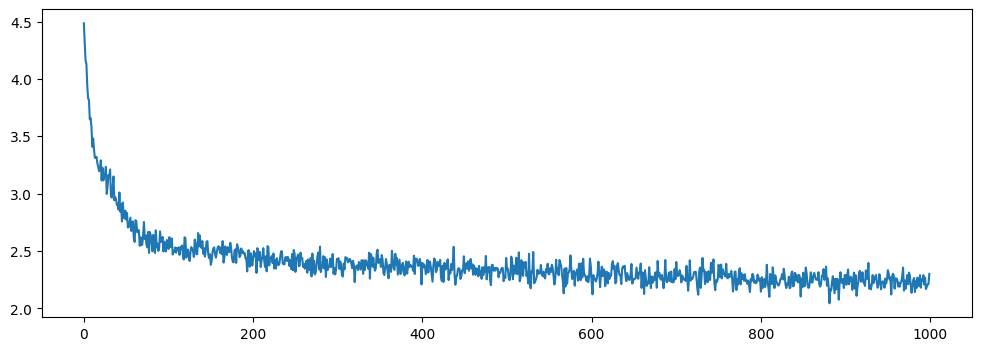

In [142]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(12, 4))
plt.plot(lossi)
